Sau khi cài đặt môi trường và gói API Object_detecttion ta tiến hành chạy file model_builder_tf2_test.py để xác nhận toàn bộ môi trường đã được cài đặt đúng, bao gồm:

- TensorFlow 2.x

- Object Detection API

- Protobuf đã biên dịch

- Thư viện phụ thuộc (tf_slim, absl, pycocotools, v.v.)

- Cấu trúc thư mục và PYTHONPATH chính xác

In [ ]:
# Run Model Bulider Test file, just to verify everything's working properly
!python models/research/object_detection/builders/model_builder_tf2_test.py

2025-11-09 15:50:13.043111: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/
2025-11-09 15:50:13.043149: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
/home/hoang_anh/miniconda3/envs/embedded/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
2025-11-09 15:50:15.570765: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read

TensorFlow Object Detection API không đọc trực tiếp các định dạng annotation thông thường như:

- XML (PASCAL VOC)

- JSON của LabelMe

- TXT YOLO

- CSV tùy chỉnh

- Danh sách nhãn rời rạc

Mà mô hình chỉ chấp nhận duy nhất định dạng:

-  TFRecord (.tfrecord)
-  Label map (.pbtxt)

Vì vậy, bất kỳ bộ dữ liệu nào muốn sử dụng cho TensorFlow Object Detection đều phải được chuyển đổi sang TFRecord.
Hai file dưới đây giúp chuyến dữ liệu từ dạng annotation về csv và tfrecord

In [12]:
# Download data conversion scripts
! wget https://raw.githubusercontent.com/EdjeElectronics/TensorFlow-Lite-Object-Detection-on-Android-and-Raspberry-Pi/master/util_scripts/create_csv.py
! wget https://raw.githubusercontent.com/EdjeElectronics/TensorFlow-Lite-Object-Detection-on-Android-and-Raspberry-Pi/master/util_scripts/create_tfrecord.py

--2025-11-09 16:11:17--  https://raw.githubusercontent.com/EdjeElectronics/TensorFlow-Lite-Object-Detection-on-Android-and-Raspberry-Pi/master/util_scripts/create_csv.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8000::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1348 (1,3K) [text/plain]
Saving to: ‘create_csv.py’

create_csv.py       100%[===================>]   1,32K  --.-KB/s    in 0s      

2025-11-09 16:11:17 (32,5 MB/s) - ‘create_csv.py’ saved [1348/1348]

--2025-11-09 16:11:17--  https://raw.githubusercontent.com/EdjeElectronics/TensorFlow-Lite-Object-Detection-on-Android-and-Raspberry-Pi/master/util_scripts/create_tfrecord.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8000::154, 2606:50c0:8002::154, ...
Connecting to raw.gith

Kiểm tra file TfRecord vừa tạo và kiểm tra đã nhận GPU chưa

In [24]:
import tensorflow as tf
from object_detection.builders import model_builder

# Kiểm tra TFRecord
raw_dataset = tf.data.TFRecordDataset("/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicletrain.tfrecord")
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())
    print("Sample features:", example.features.feature.keys())

# Kiểm tra API và GPU
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Sample features: KeysView({'image/object/class/text': bytes_list {
  value: "car"
  value: "car"
  value: "motorbike"
  value: "motorbike"
  value: "car"
  value: "motorbike"
  value: "motorbike"
  value: "motorbike"
}
, 'image/width': int64_list {
  value: 416
}
, 'image/object/bbox/xmax': float_list {
  value: 0.44711539149284363
  value: 0.723557710647583
  value: 0.6009615659713745
  value: 0.7668269276618958
  value: 0.9471153616905212
  value: 0.8990384340286255
  value: 0.9927884340286255
  value: 0.7716346383094788
}
, 'image/object/bbox/ymax': float_list {
  value: 0.3822115361690521
  value: 0.39423078298568726
  value: 0.4639423191547394
  value: 0.4711538553237915
  value: 0.5625
  value: 0.6706730723381042
  value: 0.7331730723381042
  value: 0.9975961446762085
}
, 'image/encoded': bytes_list {
  value: "\377\330\377\340\000\020JFIF\000\001\001\000\000\001\000\001\000\000\377\333\000C\000\010\006\006\007\006\005\010\007\007\007\t\t\010\n\014\024\r\014\013\013\014\031\022\0

Chọn Model ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8 để dùng cho việc Retrain Model

In [ ]:
# Change the chosen_model variable to deploy different models available in the TF2 object detection zoo
chosen_model = 'ssd-mobilenet-v2-fpnlite-320'

MODELS_CONFIG = {
    'ssd-mobilenet-v2': {
        'model_name': 'ssd_mobilenet_v2_320x320_coco17_tpu-8',
        'base_pipeline_file': 'ssd_mobilenet_v2_320x320_coco17_tpu-8.config',
        'pretrained_checkpoint': 'ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz',
    },
    'efficientdet-d0': {
        'model_name': 'efficientdet_d0_coco17_tpu-32',
        'base_pipeline_file': 'ssd_efficientdet_d0_512x512_coco17_tpu-8.config',
        'pretrained_checkpoint': 'efficientdet_d0_coco17_tpu-32.tar.gz',
    },
    'ssd-mobilenet-v2-fpnlite-320': {
        'model_name': 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8',
        'base_pipeline_file': 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.config',
        'pretrained_checkpoint': 'ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz',
    },
}

model_name = MODELS_CONFIG[chosen_model]['model_name']
pretrained_checkpoint = MODELS_CONFIG[chosen_model]['pretrained_checkpoint']
base_pipeline_file = MODELS_CONFIG[chosen_model]['base_pipeline_file']

In [ ]:
# Create "mymodel" folder for holding pre-trained weights and configuration files

# Download pre-trained model weights
import tarfile
download_tar = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/' + pretrained_checkpoint
!wget {download_tar}
tar = tarfile.open(pretrained_checkpoint)
tar.extractall()
tar.close()

# Download training configuration file for model
download_config = 'https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/configs/tf2/' + base_pipeline_file
!wget {download_config}

mkdir: cannot create directory ‘/content/models/mymodel/’: No such file or directory
[Errno 2] No such file or directory: '/content/models/mymodel/'
/home/hoang_anh/BEV
--2025-11-09 17:32:26--  http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 2404:6800:4005:817::201b, 2404:6800:4005:814::201b, 2404:6800:4005:826::201b, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|2404:6800:4005:817::201b|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20515344 (20M) [application/x-tar]
Saving to: ‘ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz’

ssd_mobilenet_v2_fp 100%[===================>]  19,56M  1,63MB/s    in 12s     

2025-11-09 17:32:40 (1,66 MB/s) - ‘ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz’ saved [20515344/20515344]

--2025-11-09 17:32:40--  https://raw.githubusercontent.com/tensorflow/models/ma

Coppy Model ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8 vào thư mục và cấu hình cho file config để phù hợp với bộ dữ liệu huấn luyện

In [ ]:
import os, re

os.chdir("mymodel")  # chuyển vào thư mục model
print(" Writing custom configuration file")

pipeline_fname = "ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config"
train_record_fname = "../train.tfrecord"
val_record_fname = "../test.tfrecord"
label_map_pbtxt_fname = "../label_map.pbtxt"
fine_tune_checkpoint = "ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/checkpoint/ckpt-0"
num_classes = 4
batch_size = 16
num_steps = 25000
chosen_model = "ssd-mobilenet-v2"

with open(pipeline_fname) as f:
    s = f.read()

s = re.sub('fine_tune_checkpoint: ".*?"',
           f'fine_tune_checkpoint: "{fine_tune_checkpoint}"', s)
s = re.sub('input_path: ".*?train.*?"',
           f'input_path: "{train_record_fname}"', s)
s = re.sub('input_path: ".*?val.*?"',
           f'input_path: "{val_record_fname}"', s)
s = re.sub('label_map_path: ".*?"',
           f'label_map_path: "{label_map_pbtxt_fname}"', s)
s = re.sub('batch_size: [0-9]+', f'batch_size: {batch_size}', s)
s = re.sub('num_steps: [0-9]+', f'num_steps: {num_steps}', s)
s = re.sub('num_classes: [0-9]+', f'num_classes: {num_classes}', s)
s = re.sub('fine_tune_checkpoint_type: "classification"',
           'fine_tune_checkpoint_type: "detection"', s)

if chosen_model == "ssd-mobilenet-v2":
    s = re.sub('learning_rate_base: .8', 'learning_rate_base: .08', s)
    s = re.sub('warmup_learning_rate: 0.13333', 'warmup_learning_rate: .026666', s)

with open("../pipeline.config", "w") as f:
    f.write(s)

print(" Done. New config saved to pipeline_file.config")


 Writing custom configuration file
 Done. New config saved to pipeline_file.config


Kiểm tra lại file config sau khi thay đổi

In [ ]:
!cat /home/hoang_anh/BEV/pipeline.config

model {
  ssd {
    num_classes: 4
    image_resizer {
      fixed_shape_resizer {
        height: 320
        width: 320
      }
    }
    feature_extractor {
      type: "ssd_mobilenet_v2_fpn_keras"
      depth_multiplier: 1.0
      min_depth: 16
      conv_hyperparams {
        regularizer {
          l2_regularizer {
            weight: 3.9999998989515007e-05
          }
        }
        initializer {
          random_normal_initializer {
            mean: 0.0
            stddev: 0.009999999776482582
          }
        }
        activation: RELU_6
        batch_norm {
          decay: 0.996999979019165
          scale: true
          epsilon: 0.0010000000474974513
        }
      }
      use_depthwise: true
      override_base_feature_extractor_hyperparams: true
      fpn {
        min_level: 3
        max_level: 7
        additional_layer_depth: 128
      }
    }
    box_coder {
      faster_rcnn_box_coder {
        y_scale: 10.0
        x_scale: 10.0
        height_scale: 5.0
 

Kiểm tra GPU trước khi huấn luyện

In [3]:
import tensorflow as tf

# Kiểm tra phiên bản TensorFlow
print("TensorFlow version:", tf.__version__)

# Kiểm tra số GPU có sẵn
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
print("GPUs:", gpus)


TensorFlow version: 2.8.4
Num GPUs Available: 1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Tiến hành Retrain Model

In [4]:

!python /home/hoang_anh/BEV/models/research/object_detection/model_main_tf2.py \
    --pipeline_config_path=/home/hoang_anh/BEV/mymodel/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config \
    --model_dir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training \
    --alsologtostderr \
    --num_train_steps=25000 \
    --sample_1_of_n_eval_examples=1

/home/hoang_anh/miniconda3/envs/embedded/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/home/hoang_anh/miniconda3/envs/embedded/lib/python3.10/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.8.4 and is not supported. 
Some things might work, some things might not.
If you were to encounter a b

Export Model dạng save_model.pb để test

In [5]:
!python /home/hoang_anh/BEV/models/research/object_detection/exporter_main_v2.py \
    --input_type=image_tensor \
    --pipeline_config_path=/home/hoang_anh/BEV/mymodel/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config \
    --trained_checkpoint_dir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training \
    --output_directory=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/exported_model

2025-11-14 08:13:09.506178: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-14 08:13:09.536174: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-14 08:13:09.538199: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-14 08:13:09.544173: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

Dự đoán trên ảnh tĩnh

2025-11-15 00:00:29.482811: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-15 00:00:29.512017: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-15 00:00:29.514297: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-11-15 00:00:29.516567: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

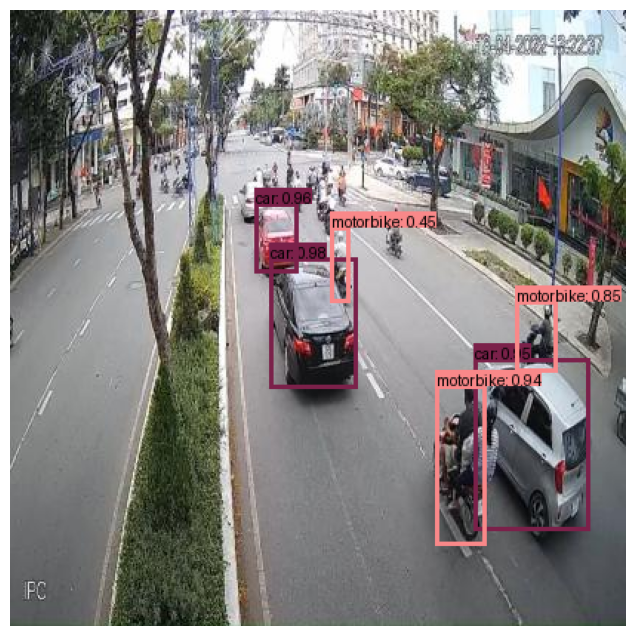

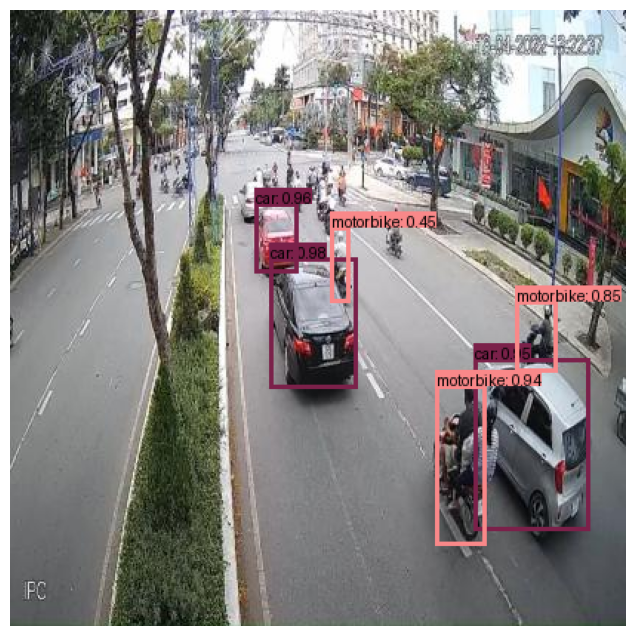

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from object_detection.utils import label_map_util

# --- 1. Load mô hình  ---
# Tải toàn bộ SavedModel
loaded_model = tf.saved_model.load("/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/exported_model/saved_model")
# Lấy hàm dự đoán (serving function) từ signature 'serving_default'
detect_fn = loaded_model.signatures['serving_default'] 

# --- 2. Load label map ---
PATH_TO_LABELS = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicle_label_map.pbtxt"  
category_index = label_map_util.create_category_index_from_labelmap(PATH_TO_LABELS, use_display_name=True)

# --- 3. Load ảnh ---
image_path = "/home/hoang_anh/BEV/images/train/camDLHB-13h20---13h57_mp4-15_jpg.rf.3431dc90ce5658631556e22f0afbd1b7.jpg"
image_np = np.array(Image.open(image_path))

# Cần convert ảnh sang tensor (dtype=tf.uint8) và mở rộng chiều batch size
input_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8) 
input_tensor = input_tensor[tf.newaxis, ...]  # batch size = 1

# --- 4. Chạy dự đoán ---
# Lưu ý: Input của detect_fn cần là tensor uint8 có shape [1, H, W, 3]
detections = detect_fn(input_tensor)

# Xử lý output
num_detections = int(detections.pop('num_detections'))
# Chuyển các tensor output về numpy array
detections = {key: value[0, :num_detections].numpy() for key, value in detections.items()}
boxes = detections['detection_boxes']
scores = detections['detection_scores']
# Chú ý: trong signature 'serving_default', khóa classes là 'detection_classes'
classes = detections['detection_classes'].astype(np.int32) 

# --- 5. Vẽ tất cả bounding boxes với tên class (Đã sửa lỗi textsize) ---
image_pil = Image.fromarray(image_np)
draw = ImageDraw.Draw(image_pil)

# Tạo màu khác nhau cho mỗi class (Giữ lại logic này)
colors = {}
for class_id in np.unique(classes):
    # Đảm bảo colors[class_id] là tuple của int
    colors[class_id] = tuple(np.random.randint(0, 256, size=3).tolist()) 

im_width, im_height = image_pil.size

# Thử load font để vẽ chữ đẹp hơn (Nếu có lỗi, nó sẽ dùng font mặc định)
try:
    font = ImageFont.truetype("arial.ttf", 20) 
except IOError:
    font = ImageFont.load_default()

# Lặp qua TẤT CẢ các đối tượng đã phát hiện
for i in range(num_detections):
    # Chỉ vẽ box nếu độ tin cậy >= 0.5
    if scores[i] >= 0.4:
        ymin, xmin, ymax, xmax = boxes[i]
        (left, right, top, bottom) = (xmin * im_width, xmax * im_width,
                                      ymin * im_height, ymax * im_height)
        
        # Đảm bảo tọa độ là số nguyên
        left, right, top, bottom = int(left), int(right), int(top), int(bottom)
        
        class_id = classes[i]
        color = colors[class_id]
        
        # Vẽ box
        draw.rectangle([(left, top), (right, bottom)], outline=color, width=3)
        
        # Lấy tên class
        class_name = category_index[class_id]['name'] if class_id in category_index else str(class_id)
        text_to_display = f"{class_name}: {scores[i]:.2f}"
        
        # TÍNH TOÁN KÍCH THƯỚC TEXT (SỬA LỖI textsize)
        text_position = (left, top)
        # Bbox trả về (x_min, y_min, x_max, y_max)
        bbox = draw.textbbox(text_position, text_to_display, font=font)
        
        # Chiều rộng và chiều cao của text
        text_w = bbox[2] - bbox[0] 
        text_h = bbox[3] - bbox[1]
        
        # Vẽ background cho chữ (nằm ngay trên box)
        draw.rectangle([(left, top - text_h - 2), (left + text_w, top)], fill=color)
        
        # Vẽ chữ
        draw.text((left + 1, top - text_h - 1), text_to_display, fill=(0, 0, 0), font=font)

# --- 6. Hiển thị ảnh ---
plt.figure(figsize=(12, 8))
plt.imshow(image_pil)
plt.axis('off')
plt.show()

# --- 7. Lưu ảnh dự đoán nếu muốn ---
image_pil.save("test_predicted.jpg")
# --- 6. Hiển thị ảnh ---
plt.figure(figsize=(12, 8))
plt.imshow(image_pil)
plt.axis('off')
plt.show()

# --- 7. Lưu ảnh dự đoán nếu muốn ---
image_pil.save("test_predicted.jpg")

Dự đoán trên đoạn video

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # ép dùng CPU
import tensorflow as tf
import cv2
import numpy as np
from object_detection.utils import label_map_util
import time

# ---------- THAM SỐ ----------
VIDEO_PATH = "/home/hoang_anh/BEV/CongHoa-UtTich1 2017-07-17_14.15.asf"
OUTPUT_PATH = "/home/hoang_anh/BEV/output_30fps.avi"
MODEL_DIR = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/exported_model/saved_model"
LABEL_MAP = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicle_label_map.pbtxt"
SCORE_THRESH = 0.2
RESIZE = (320, 320)
TARGET_FPS = 30      # xuất ra 30fps
MAX_SECONDS = 30     # chỉ xử lý 30 giây đầu

# ---------- LOAD MODEL ----------
print("Loading model...")
model = tf.saved_model.load(MODEL_DIR)
detect_fn = model.signatures['serving_default']
category_index = label_map_util.create_category_index_from_labelmap(LABEL_MAP, use_display_name=True)
print("Model ready.")

# ---------- OPEN VIDEO ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise SystemExit(f"Cannot open video {VIDEO_PATH}")

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = int(cap.get(cv2.CAP_PROP_FPS) or 25)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FRAME_LIMIT = min(TARGET_FPS * MAX_SECONDS, TOTAL_FRAMES)

fourcc = cv2.VideoWriter_fourcc(*'MJPG')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, TARGET_FPS, (W, H))

# ---------- PROCESS ----------
print(f"Processing at 30 FPS for {MAX_SECONDS}s (~{FRAME_LIMIT} frames)...")

frame_idx = 0
start_time_global = time.time()

while frame_idx < FRAME_LIMIT:
    ret, frame = cap.read()
    if not ret:
        break

    # Giảm tốc độ xử lý xuống 30fps (bỏ bớt frame nếu video gốc cao hơn)
    if FPS > TARGET_FPS and frame_idx % int(FPS / TARGET_FPS) != 0:
        frame_idx += 1
        continue

    t0 = time.time()

    # Resize frame về 320x320
    frame_resized = cv2.resize(frame, RESIZE)
    
    # 1. CHUẨN HÓA ĐÚNG CÁCH (XÓA BƯỚC CHUẨN HÓA FLOAT)
    # SavedModel yêu cầu BGR -> RGB và Dtype uint8 (0-255)
    frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
    
    # 2. Tạo Input Tensor
    # PHẢI LÀ DTYPE tf.uint8 như mô hình SavedModel mong đợi
    input_tensor = tf.convert_to_tensor(frame_rgb, dtype=tf.uint8)[tf.newaxis, ...]
    
    # Detect
    det = detect_fn(input_tensor)
    
    # Lấy kết quả
    num = int(det.pop('num_detections'))
    det = {k: v[0, :num].numpy() for k, v in det.items()}
    boxes = det['detection_boxes']
    scores = det['detection_scores']
    classes = det['detection_classes'].astype(np.int32)

    # Vẽ box trên frame gốc (dựa theo tỉ lệ gốc)
    for i in range(num):
        if scores[i] < SCORE_THRESH: continue
        ymin, xmin, ymax, xmax = boxes[i]
        
        # Chuyển đổi tọa độ chuẩn hóa (0-1) sang tọa độ pixel (0-W/H)
        left = int(xmin * W)
        right = int(xmax * W)
        top = int(ymin * H)
        bottom = int(ymax * H)
        
        cls = int(classes[i])
        label = f"{category_index.get(cls, {'name':str(cls)})['name']}:{scores[i]:.2f}"
        
        cv2.rectangle(frame, (left, top), (right, bottom), (0,255,0), 2)
        # Đổi màu text của label thành Đỏ (BGR: 0, 0, 255)
        cv2.putText(frame, label, (left, max(15, top-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    # Tính FPS thực
    t1 = time.time()
    fps_now = 1.0 / max(1e-3, (t1 - t0))
    # FPS là màu Đỏ (BGR: 0, 0, 255)
    cv2.putText(frame, f"FPS: {fps_now:.1f}", (20,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

    out.write(frame)
    frame_idx += 1

    # Giữ tốc độ xuất 30fps (ngủ phần còn lại)
    elapsed = time.time() - t0
    wait_time = max(0, (1.0 / TARGET_FPS) - elapsed)
    time.sleep(wait_time)

cap.release()
out.release()
print(f"Done! Saved: {OUTPUT_PATH}")

Loading model...


2025-11-15 07:43:12.377252: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-11-15 07:43:12.377302: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: hoang-anh-Precision-7550
2025-11-15 07:43:12.377318: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: hoang-anh-Precision-7550
2025-11-15 07:43:12.377449: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 580.95.5
2025-11-15 07:43:12.377503: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 580.95.5
2025-11-15 07:43:12.377519: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 580.95.5
2025-11-15 07:43:12.377887: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instruc

Model ready.
Processing at 30 FPS for 30s (~900 frames)...
Done! Saved: /home/hoang_anh/BEV/output_30fps.avi


Chạy dự đoán trên tập Test và tính mAP

In [6]:
!python /home/hoang_anh/BEV/models/research/object_detection/model_main_tf2.py \
--logtostderr \
--model_dir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training \
--pipeline_config_path=/home/hoang_anh/BEV/mymodel/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/pipeline.config \
--checkpoint_dir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training \
--eval_dir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training/eval_results

/home/hoang_anh/miniconda3/envs/embedded/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/home/hoang_anh/miniconda3/envs/embedded/lib/python3.10/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.8.4 and is not supported. 
Some things might work, some things might not.
If you were to encounter a b

Xem kết quả phân tích trên TensorBoard (mAP,Loss,image,...) 

In [ ]:
!tensorboard --logdir=/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/training


Tối ưu hóa detection bằng cách cắt bỏ vùng dư ( cụ thể là vùng trời phía trên video) chỉ lấy phần còn lại resize 320x320 r đưa vào input cho mô hình dự đoán

In [ ]:
import os
import tensorflow as tf
import cv2
import numpy as np
from object_detection.utils import label_map_util
import time

# =================================================================
# QUAN TRỌNG: ÉP DÙNG CPU ĐỂ MÔ PHỎNG MÔI TRƯỜNG EMBEDDED
# =================================================================
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  
print("Cảnh báo: Đang ép dùng CPU cho suy luận để đánh giá hiệu suất nền tảng embedded/mobile.")
# Kiểm tra lại xem GPU có bị tắt không
if len(tf.config.experimental.list_physical_devices('GPU')) > 0:
    print("WARNING: GPU devices still detected. Inference may use GPU if TF configuration is not fully strict.")
else:
    print("SUCCESS: No GPU detected by TensorFlow. Running on CPU.")


# ---------- THAM SỐ ----------
VIDEO_PATH = "/home/hoang_anh/BEV/CongHoa-UtTich1 2017-07-17_14.15.asf"
# Đổi tên output để phản ánh 30% crop
OUTPUT_PATH = "/home/hoang_anh/BEV/output_30fps_cpu_inf_road_crop_30pct.avi" 
MODEL_DIR = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/exported_model/saved_model"
LABEL_MAP = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicle_label_map.pbtxt"
SCORE_THRESH = 0.2
RESIZE = (320, 320)
TARGET_FPS = 30      # FPS mong muốn cho video đầu ra
MAX_SECONDS = 30     # chỉ xử lý 30 giây đầu
# ĐÃ SỬA: Tỉ lệ cắt bầu trời thành 30%
CROP_RATIO = 0.30    # Tỉ lệ chiều cao (từ trên xuống) để bỏ qua (30% bầu trời)

# ---------- LOAD MODEL ----------
print("\nLoading model...")
try:
    model = tf.saved_model.load(MODEL_DIR)
except Exception as e:
    print(f"Lỗi khi tải SavedModel: {e}")
    raise SystemExit("Vui lòng đảm bảo MODEL_DIR là đường dẫn chính xác đến thư mục SavedModel đã xuất.")

detect_fn = model.signatures['serving_default']
category_index = label_map_util.create_category_index_from_labelmap(LABEL_MAP, use_display_name=True)
print("Model ready.")

# ---------- OPEN VIDEO ----------
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise SystemExit(f"Cannot open video {VIDEO_PATH}")

W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_INPUT = int(cap.get(cv2.CAP_PROP_FPS) or 25)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FRAME_LIMIT = min(TARGET_FPS * MAX_SECONDS, TOTAL_FRAMES)

# Khởi tạo VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'MJPG')
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, TARGET_FPS, (W, H))

# ---------- LOGIC CROP ----------
# Bắt đầu crop từ 30% chiều cao
y_start_crop = int(H * CROP_RATIO)  
y_end_crop = H                      
effective_height = y_end_crop - y_start_crop 
y_offset = y_start_crop             

# ---------- PROCESS ----------
print(f"\nBắt đầu xử lý video:")
print(f" - Video gốc: {W}x{H} @ {FPS_INPUT} FPS")
print(f" - Vùng Suy luận (Road/Xe cộ): Từ {y_start_crop} đến {y_end_crop} ({effective_height} pixels)")
print(f" - Xử lý tối đa: {FRAME_LIMIT} frames (~{MAX_SECONDS} giây)")
print(f" - Đầu ra: {W}x{H} @ {TARGET_FPS} FPS (dùng {RESIZE[0]}x{RESIZE[1]} cho suy luận)")

frame_idx = 0
inference_times = [] 
frame_skip_factor = max(1, round(FPS_INPUT / TARGET_FPS))

while frame_idx < TOTAL_FRAMES and frame_idx < FRAME_LIMIT:
    ret, frame = cap.read()
    if not ret:
        break

    # Điều chỉnh tốc độ xử lý để xuất ra TARGET_FPS
    if FPS_INPUT > TARGET_FPS and frame_idx % frame_skip_factor != 0:
        frame_idx += 1
        continue
    
    # --- BẮT ĐẦU SUY LUẬN ---
    t0 = time.time()

    # 1. Cắt (Crop) phần dưới (từ y_start_crop đến H)
    frame_cropped = frame[y_start_crop:y_end_crop, 0:W]
    
    # 2. Tiền xử lý (Resize về 320x320 và BGR -> RGB)
    frame_resized = cv2.resize(frame_cropped, RESIZE)
    frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
    
    # 3. Tạo Input Tensor và Detect
    input_tensor = tf.convert_to_tensor(frame_rgb, dtype=tf.uint8)[tf.newaxis, ...]
    det = detect_fn(input_tensor)
    
    # Lấy kết quả
    num = int(det.pop('num_detections'))
    det = {k: v[0, :num].numpy() for k, v in det.items()}
    boxes = det['detection_boxes']
    scores = det['detection_scores']
    classes = det['detection_classes'].astype(np.int32)
    
    t1 = time.time()
    inference_time = t1 - t0
    inference_times.append(inference_time)
    
    # --- HẬU XỬ LÝ & VẼ BOX ---
    
    # Vẽ box trên frame gốc (dựa theo tỉ lệ gốc)
    for i in range(num):
        if scores[i] < SCORE_THRESH: continue
        
        # Tọa độ chuẩn hóa trên ảnh crop
        ymin_norm, xmin_norm, ymax_norm, xmax_norm = boxes[i]
        
        # CHUYỂN ĐỔI VỊ TRÍ (MAP POSITION)
        # X: Tọa độ X vẫn là 0 -> W (không thay đổi)
        left = int(xmin_norm * W)
        right = int(xmax_norm * W)
        
        # Y: Ánh xạ tọa độ Y chuẩn hóa (0-1) về tọa độ pixel trên vùng CROP (0 đến effective_height)
        # Sau đó cộng thêm Y offset (y_start_crop)
        top_on_crop = int(ymin_norm * effective_height) 
        bottom_on_crop = int(ymax_norm * effective_height)
        
        # Tọa độ trên frame gốc
        top = top_on_crop + y_offset
        bottom = bottom_on_crop + y_offset
        
        cls = int(classes[i])
        # Lấy nhãn và định dạng
        label_text = category_index.get(cls, {'name':str(cls)})['name']
        display_text = f" {label_text}: {scores[i]:.2f}"
        
        # Màu box: Xanh lá (BGR: 0, 255, 0)
        cv2.rectangle(frame, (left, top), (right, bottom), (0,255,0), 2)
        
        # Màu text: Đỏ (BGR: 0, 0, 255)
        cv2.putText(frame, display_text, (left, max(15, top-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    # Tính FPS thực tế (dựa trên thời gian suy luận)
    fps_now = 1.0 / max(1e-6, inference_time) # Tránh chia cho 0
    
    # Hiển thị FPS suy luận và thông báo CPU (Màu Đỏ)
    cv2.putText(frame, f"Inf. FPS (CPU): {fps_now:.1f}", (20,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
    cv2.putText(frame, f"CROP MODE: ROAD ({CROP_RATIO*100:.0f}%->100%)", (20,90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,165,0), 2)


    out.write(frame)
    frame_idx += 1


cap.release()
out.release()

# Tính toán FPS trung bình
if inference_times:
    avg_inf_time = np.mean(inference_times)
    avg_fps = 1.0 / avg_inf_time
    print(f" - Thời gian suy luận trung bình: {avg_inf_time * 1000:.2f} ms")
    print(f" - Average FPS (CPU): {avg_fps:.1f} FPS")
    print(f" - Video đầu ra được lưu tại: {OUTPUT_PATH}")

print("Hoàn thành!")

Cảnh báo: Đang ép dùng CPU cho suy luận để đánh giá hiệu suất nền tảng embedded/mobile.
SUCCESS: No GPU detected by TensorFlow. Running on CPU.

Loading model...
Model ready.

Bắt đầu xử lý video:
 - Video gốc: 800x450 @ 25 FPS
 - Vùng Suy luận (Road/Xe cộ): Từ 135 đến 450 (315 pixels)
 - Xử lý tối đa: 900 frames (~30 giây)
 - Đầu ra: 800x450 @ 30 FPS (dùng 320x320 cho suy luận)
 - Thời gian suy luận trung bình: 75.73 ms
 - Average FPS (CPU): 13.2 FPS
 - Video đầu ra được lưu tại: /home/hoang_anh/BEV/output_30fps_cpu_inf_road_crop_30pct.avi
Hoàn thành!


Vẽ Confusion Matrix

Classes = ['bus', 'car', 'motorbike', 'truck']
Loading model...
Model loaded!


2025-11-15 20:04:30.616547: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8101


DONE inference!
Total samples used: 214


<Figure size 600x600 with 0 Axes>

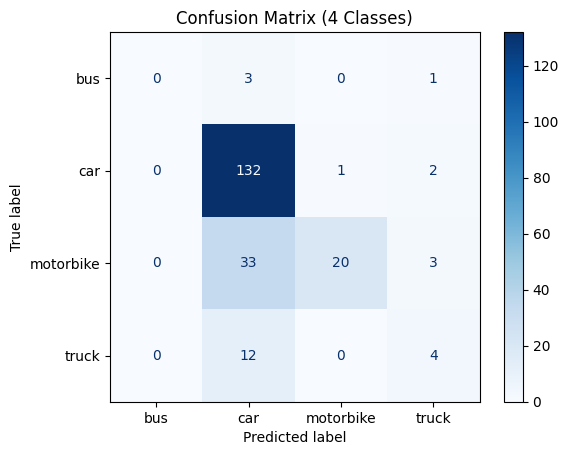

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from object_detection.utils import label_map_util

# ================================
# 1. ĐƯỜNG DẪN
# ================================
TFRECORD_PATH = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicle_test.tfrecord"
SAVED_MODEL_DIR = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/exported_model/saved_model"
LABELMAP = "/home/hoang_anh/BEV/ssdlite_mobilenet_v2_coco_2018_05_09/vehicle_label_map.pbtxt"

# ================================
# 2. LOAD LABEL MAP
# ================================
category_index = label_map_util.create_category_index_from_labelmap(LABELMAP)
class_names = [category_index[k]["name"] for k in category_index.keys()]
print("Classes =", class_names)

# ================================
# 3. HÀM PARSE TFRECORD — ĐÃ SỬA
# ================================
def parse_tfrecord(example):
    features = {
        "image/encoded": tf.io.FixedLenFeature([], tf.string),
        "image/object/class/label": tf.io.VarLenFeature(tf.int64)
    }
    parsed = tf.io.parse_single_example(example, features)

    image = tf.image.decode_jpeg(parsed["image/encoded"], channels=3)
    labels = tf.sparse.to_dense(parsed["image/object/class/label"])   # int64

    # Nếu không có object → label = -1 (dtype int64)
    label = tf.cond(
        tf.size(labels) > 0,
        lambda: labels[0],
        lambda: tf.constant(-1, dtype=tf.int64)
    )

    return image, label

# ================================
# LOAD DATASET
# ================================
dataset = tf.data.TFRecordDataset(TFRECORD_PATH).map(parse_tfrecord)

# ================================
# 4. LOAD SAVED MODEL
# ================================
print("Loading model...")
detector = tf.saved_model.load(SAVED_MODEL_DIR)
infer = detector.signatures["serving_default"]
print("Model loaded!")

# ================================
# 5. CHẠY INFERENCE
# ================================
y_true = []
y_pred = []

for image, label in dataset:
    img = tf.expand_dims(image, 0)
    result = infer(img)

    scores = result["detection_scores"][0].numpy()
    classes = result["detection_classes"][0].numpy().astype(int)

    if scores[0] > 0.5:
        pred = classes[0]
    else:
        pred = -1

    if label.numpy() != -1:
        y_true.append(int(label.numpy()))
        y_pred.append(int(pred))

print("DONE inference!")
print("Total samples used:", len(y_true))

# ================================
# 6. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_true, y_pred, labels=list(category_index.keys()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix (4 Classes)")
plt.show()
